# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    LaplaceThompsonViaBayesianLogRegPolicy,
    NeuralLaplaceThompsonViaBayesianLogRegPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    TreeThompsonSamplingPolicy,
    TreeThompsonSamplingPolicyDummyRefit,
    TreeThompsonSamplingPolicyUpdateV1,
    CustomTreeThompsonSamplingPolicyUpdateV1,
    _NeuralActionRewardEncoder,
    build_expected_reward_estimator,
    default_scenario,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    run_scenarios_ips,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [15]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'cdp_music_fs_small.tsv'
DATASET_NAME = DATA_PATH.stem
ARTIFACTS_DIR = ROOT / 'artifacts' / DATASET_NAME
DATASETS_DIR = ARTIFACTS_DIR / 'datasets'
PREPARED_TRAIN_PATH = DATASETS_DIR / 'train_variant_1_scaled.parquet'
PREPARED_TEST_PATH = DATASETS_DIR / 'test_variant_1_scaled.parquet'
USE_PREPARED_SPLITS = True
TRAIN_DAYS = 20
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = False
NEURAL_HIDDEN_DIMS = [128, 68]
USE_SAMPLED_DATASET = True
SAMPLE_FRACTION = 0.2  # доля строк для train/test при демо-прогоне
USE_CUSTOM_ENCODER = True
ENCODER_REP_DIM = 32
ENCODER_NN_LR = 1e-3
ENCODER_TRAIN_DATA_MODE = 'random_half'  # all | random_half | time_half


BOOTSTRAP_ENABLED = True
BOOTSTRAP_ITERATIONS = 100
BOOTSTRAP_CI = 0.95


TREE_UPDATE_C_MIN_GRID = [1, 5]
TREE_UPDATE_MIN_SAMPLES_LEAF_GRID = [150, 300]
TREE_UPDATE_MAX_DEPTH_GRID = [3, 4]


## 2) Загрузка и препроцессинг

In [16]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(DATASETS_DIR), TRAIN_DAYS, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(DATASETS_DIR))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 1772191 test(random only): 3241836


## 3) Конфиг политик и сценариев

In [21]:
policy_factories = {
    "good": lambda: TreeThompsonSamplingPolicyUpdateV1(
        random_state=SEED,
        c_min=20,
        min_samples_leaf=3000,
        max_depth=3
    ),
    "test1": lambda: CustomTreeThompsonSamplingPolicyUpdateV1(
        random_state=SEED,
        c_min=20,
        min_samples_leaf=3000,
        max_depth=3,
        split_criterion = "beta_marginal_likelihood"
    ),
    "test2": lambda: CustomTreeThompsonSamplingPolicyUpdateV1(
        random_state=SEED,
        c_min=20,
        min_samples_leaf=3000,
        max_depth=3,
        split_criterion = "bernoulli_log_likelihood"
    ),
    
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
    # 'random': lambda: RandomPolicy(seed=SEED),
    # 'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    # 'ucb': lambda: UCBPolicy(),
}

# try:
#     import sklearn  # noqa: F401
#     policy_factories['tree_thompson_sampling_refit'] = lambda: TreeThompsonSamplingPolicyDummyRefit(random_state=SEED)
#     for c_min in TREE_UPDATE_C_MIN_GRID:
#         for min_samples_leaf in TREE_UPDATE_MIN_SAMPLES_LEAF_GRID:
#             for max_depth in TREE_UPDATE_MAX_DEPTH_GRID:
#                 key = f'tree_thompson_sampling_update_d{max_depth}_l{min_samples_leaf}_c{c_min}'
#                 policy_factories[key] = (
#                     lambda c_min=c_min, min_samples_leaf=min_samples_leaf, max_depth=max_depth:
#                     TreeThompsonSamplingPolicyUpdateV1(
#                         random_state=SEED,
#                         c_min=c_min,
#                         min_samples_leaf=min_samples_leaf,
#                         max_depth=max_depth,
#                     )
#                 )
# except Exception:
#     print('sklearn is unavailable: skipping TreeThompsonSamplingPolicy')
# try:
#     import scipy  # noqa: F401
#     policy_factories['laplace_ts_logreg'] = lambda: LaplaceThompsonViaBayesianLogRegPolicy(seed=SEED)
#     try:
#         import torch  # noqa: F401
#         custom_encoder = None
#         if USE_CUSTOM_ENCODER:
#             feature_rows = train_df.select('features_list').to_series().to_list()
#             non_empty_features = [row for row in feature_rows if isinstance(row, list) and len(row) > 0]
#             if non_empty_features:
#                 feature_dim = len(non_empty_features[0])
#                 action_count = train_df.select('show').n_unique()
#                 custom_encoder = _NeuralActionRewardEncoder(
#                     input_dim=feature_dim,
#                     num_actions=action_count,
#                     hidden_dims=NEURAL_HIDDEN_DIMS,
#                     rep_dim=ENCODER_REP_DIM,
#                     lr=ENCODER_NN_LR,
#                     seed=SEED,
#                 )
#             else:
#                 print('train_df has no non-empty features_list rows: encoder will be created by policy itself')
#         policy_factories['neural_laplace_ts_logreg'] = lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(
#             seed=SEED,
#             hidden_dims=NEURAL_HIDDEN_DIMS,
#             encoder=custom_encoder,
#             encoder_train_data_mode=ENCODER_TRAIN_DATA_MODE,
#         )
#     except Exception:
#         print('torch is unavailable: skipping NeuralLaplaceThompsonViaBayesianLogRegPolicy')
# except Exception:
#     print('scipy is unavailable: skipping LaplaceThompsonViaBayesianLogRegPolicy')
# try:
#     import catboost  # noqa: F401
#     policy_factories['catboost'] = lambda: CatBoostPolicy(random_seed=SEED)
# except Exception:
#     print('catboost is unavailable: skipping CatBoostPolicy')
# try:
#     import contextualbandits  # noqa: F401
#     policy_factories['logistic_ts'] = lambda: LogisticTSLibPolicy(random_seed=SEED)
#     policy_factories['partitioned_ts'] = lambda: PartitionedTSLibPolicy(random_seed=SEED)
# except Exception:
#     print('contextualbandits is unavailable: skipping LogisticTS/PartitionedTS')
scenarios = default_five_scenarios() if FULL_SCENARIOS else default_scenario()


In [22]:
if USE_SAMPLED_DATASET:
    if not (0.0 < SAMPLE_FRACTION <= 1.0):
        raise ValueError('SAMPLE_FRACTION must be in (0, 1]')
    train_eval_df = train_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
    test_eval_df = test_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
else:
    train_eval_df = train_df
    test_eval_df = test_df

print('eval train rows:', train_eval_df.height, 'of', train_df.height)
print('eval test rows:', test_eval_df.height, 'of', test_df.height)


eval train rows: 354438 of 1772191
eval test rows: 648367 of 3241836


## 4) Запуск benchmark

## 4.1) Опциональный сэмпл для быстрого прогона


In [23]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_eval_df,
    test_df=test_eval_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']
action_daily_stats_df = result['action_daily_stats']
action_sensitive_stats_df = result['action_sensitive_stats']

display(metrics_df.sort_values('ips_ctr', ascending=False).reset_index(drop=True))

ips_snips_cols = ['scenario', 'algo', 'impressions_total', 'impressions_extrapolated', 'ips_ctr', 'snips_ctr']
if set(ips_snips_cols).issubset(metrics_df.columns):
    print('IPS/SNIPS metrics (run_scenarios):')
    display(metrics_df[ips_snips_cols].sort_values(['scenario', 'algo']).reset_index(drop=True))

sensitive_cols = ['scenario', 'algo', 'sensitive_impressions', 'ips_ctr_sensitive', 'ips_regret_sens']
if set(sensitive_cols).issubset(metrics_df.columns):
    print('sensitive IPS metrics (rows with len(candidates) > 1):')
    display(metrics_df[sensitive_cols].sort_values(['ips_ctr_sensitive', 'scenario', 'algo'], ascending=[False, True, True]).reset_index(drop=True))

print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)
    display(action_daily_stats_df)
    display(action_sensitive_stats_df)


case_2_random_pretrain_online_update_daily/good:   0%| | 0/648367 [00:00<?, ?

case_2_random_pretrain_online_update_daily/good: train_unique_actions=51


case_2_random_pretrain_online_update_daily/test1:   0%| | 0/648367 [00:00<?, 

case_2_random_pretrain_online_update_daily/test1: train_unique_actions=51


case_2_random_pretrain_online_update_daily/test2:   0%| | 0/648367 [00:00<?, 

...

IPS/SNIPS metrics (run_scenarios):


,scenario,algo,impressions_total,impressions_extrapolated,ips_ctr,snips_ctr
0,case_2_random_pretrain_online_update_daily,good,648367,647895.0,0.023857,0.023874
1,case_2_random_pretrain_online_update_daily,test1,648367,649738.0,0.018466,0.018427
2,case_2_random_pretrain_online_update_daily,test2,648367,649769.0,0.018528,0.018488
3,case_2_random_pretrain_online_update_daily,thompson_sampling,648367,647262.0,0.023800,0.023840


sensitive IPS metrics (rows with len(candidates) > 1):


,scenario,algo,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens
0,case_2_random_pretrain_online_update_daily,good,300339,0.029593,0.018850
1,case_2_random_pretrain_online_update_daily,thompson_sampling,300339,0.029470,0.018897
2,case_2_random_pretrain_online_update_daily,test2,300339,0.018090,0.023145
3,case_2_random_pretrain_online_update_daily,test1,300339,0.017956,0.023218


history rows: 1904050


In [25]:
result.keys()

dict_keys(['metrics', 'history', 'action_stats', 'action_daily_stats', 'action_sensitive_stats', 'trained_models'])

In [99]:
good = result["trained_models"]["case_2_random_pretrain_online_update_daily"]["good"]
test1 = result["trained_models"]["case_2_random_pretrain_online_update_daily"]["test1"]
test2 = result["trained_models"]["case_2_random_pretrain_online_update_daily"]["test2"]

In [68]:
test1.action_models.keys()

dict_keys([2712, 2710, 7088, 7234, 8369, 2496, 6152, 2512, 8186, 7849, 2707, 7847, 8217, 7846, 8220, 7848, 4079, 7104, 7182, 7864, 7138, 7608, 7951, 7128, 1602, 7949, 6503, 7435, 5325, 5331, 7140, 7830, 5342, 7115, 7620, 7133, 7105, 8428, 5341, 8500, 8501, 8565, 8529, 8658, 8527, 8526, 7134, 8733, 8761, 8734, 8732, 8912, 8939, 8937, 8964, 8954, 8956, 8955, 8957, 9014, 8986, 9069, 9068, 9127, 9122, 9142, 9141, 9223, 9290, 9252, 9322, 9308, 9418, 9419, 9386, 9357, 9358, 9416, 9527, 9491, 9493, 9492, 9645])

In [41]:
test1.action_models[2712].tree

_CustomTreeNode(raw_count=15838, raw_clicks=200.0, weighted_count=15838.0, weighted_clicks=200.0, alpha=201.0, beta=15639.0, depth=0, leaf_id=None, feature_index=42, threshold=-1.246360783733377, left=_CustomTreeNode(raw_count=3262, raw_clicks=67.0, weighted_count=3262.0, weighted_clicks=67.0, alpha=68.0, beta=3196.0, depth=1, leaf_id=0, feature_index=None, threshold=None, left=None, right=None), right=_CustomTreeNode(raw_count=12576, raw_clicks=133.0, weighted_count=12576.0, weighted_clicks=133.0, alpha=134.0, beta=12444.0, depth=1, leaf_id=1, feature_index=None, threshold=None, left=None, right=None))

In [80]:
good.action_models[9645].tree.tree_.value

array([[[0.97488654, 0.02511346]]])

In [113]:
cnt_nodes = {k: len(v.tree.tree_.value) for k, v in good.action_models.items()}

In [125]:
from collections import Counter
Counter([v for k,v in cnt_nodes.items()])

Counter({1: 68, 7: 5, 5: 4, 3: 3, 9: 2, 11: 1})

In [137]:
cnt_nodes

{2712: 7,
 2710: 7,
 7088: 5,
 7234: 9,
 8369: 1,
 2496: 7,
 6152: 3,
 2512: 7,
 8186: 11,
 7849: 1,
 2707: 7,
 7847: 1,
 8217: 1,
 7846: 1,
 8220: 1,
 7848: 1,
 4079: 3,
 7104: 1,
 7182: 1,
 7864: 1,
 7138: 1,
 7608: 1,
 7951: 1,
 7128: 1,
 1602: 1,
 7949: 1,
 6503: 1,
 7435: 1,
 5325: 1,
 5331: 1,
 7140: 1,
 7830: 1,
 5342: 1,
 7115: 1,
 7620: 1,
 7133: 1,
 7105: 1,
 8428: 1,
 5341: 1,
 8500: 1,
 8501: 1,
 8565: 1,
 8529: 5,
 8658: 1,
 8527: 1,
 8526: 1,
 7134: 1,
 8733: 5,
 8761: 1,
 8734: 3,
 8732: 1,
 8912: 1,
 8939: 1,
 8937: 9,
 8964: 1,
 8954: 1,
 8956: 1,
 8955: 1,
 8957: 1,
 9014: 1,
 8986: 1,
 9069: 1,
 9068: 1,
 9127: 1,
 9122: 1,
 9142: 1,
 9141: 1,
 9223: 1,
 9290: 1,
 9252: 1,
 9322: 1,
 9308: 5,
 9418: 1,
 9419: 1,
 9386: 1,
 9357: 1,
 9358: 1,
 9416: 1,
 9527: 1,
 9491: 1,
 9493: 1,
 9492: 1,
 9645: 1}

In [ ]:
8186

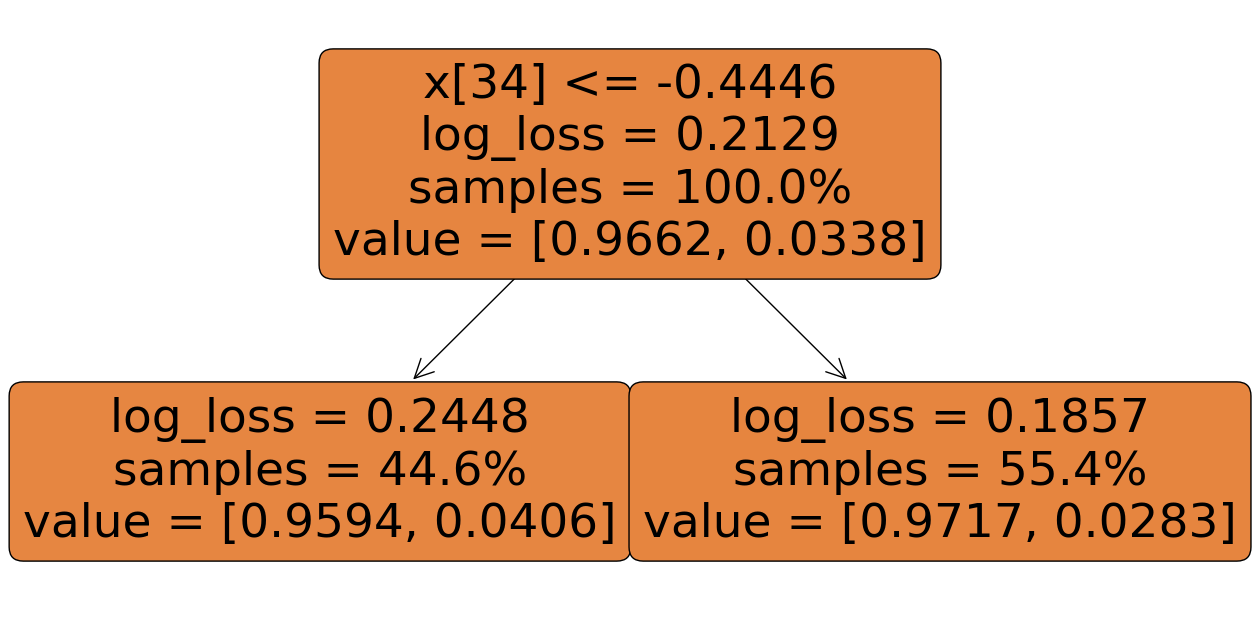

In [127]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Визуализация
plt.figure(figsize=(16, 8))
plot_tree(
    good.action_models[4079].tree,
    filled=True,
    rounded=True,
    # feature_names=load_iris().feature_names,
    # class_names=load_iris().target_names,
    impurity=True,
    proportion=True,
    precision=4,
)
plt.show()

In [128]:
test1.action_models[4079].tree

_CustomTreeNode(raw_count=12658, raw_clicks=447.0, weighted_count=12658.0, weighted_clicks=447.0, alpha=448.0, beta=12212.0, depth=0, leaf_id=0, feature_index=None, threshold=None, left=None, right=None)

In [102]:
82 / (82 + 3064)

0.026064844246662427

In [132]:
239 / 7081.0, 270 / 5986, 172.0 / 6551

(0.033752294873605426, 0.045105245573003674, 0.02625553350633491)

In [129]:
test2.action_models[4079].tree

_CustomTreeNode(raw_count=7081, raw_clicks=239.0, weighted_count=7081.0, weighted_clicks=239.0, alpha=240.0, beta=6843.0, depth=0, leaf_id=None, feature_index=34, threshold=-0.4446474659807199, left=_CustomTreeNode(raw_count=5986, raw_clicks=270.0, weighted_count=5986.0, weighted_clicks=270.0, alpha=271.0, beta=5717.0, depth=1, leaf_id=0, feature_index=None, threshold=None, left=None, right=None), right=_CustomTreeNode(raw_count=6551, raw_clicks=172.0, weighted_count=6551.0, weighted_clicks=172.0, alpha=173.0, beta=6380.0, depth=1, leaf_id=1, feature_index=None, threshold=None, left=None, right=None))

In [136]:
test2.action_models[4079].tree.left

_CustomTreeNode(raw_count=5986, raw_clicks=270.0, weighted_count=5986.0, weighted_clicks=270.0, alpha=271.0, beta=5717.0, depth=1, leaf_id=0, feature_index=None, threshold=None, left=None, right=None)

In [97]:
81 / 3220

0.02515527950310559

## 4.2) Запуск off-policy IPS/SNIPS (`run_scenarios_ips`)
Отдельный прогон с использованием `get_action_proba` вместо `select`.


In [ ]:
result_offpolicy = run_scenarios_ips(
    train_df=train_eval_df,
    test_df=test_eval_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    show_progress=True,
)
metrics_offpolicy_df = result_offpolicy['metrics']
history_offpolicy_df = result_offpolicy['history']
action_stats_offpolicy_df = result_offpolicy['action_stats']
action_daily_stats_offpolicy_df = result_offpolicy['action_daily_stats']
action_sensitive_stats_offpolicy_df = result_offpolicy['action_sensitive_stats']

display(metrics_offpolicy_df.sort_values('ips_ctr', ascending=False).reset_index(drop=True))

ips_snips_cols = ['scenario', 'algo', 'impressions_total', 'impressions_extrapolated', 'ips_ctr', 'snips_ctr']
if set(ips_snips_cols).issubset(metrics_offpolicy_df.columns):
    print('IPS/SNIPS metrics (off-policy propensity):')
    display(metrics_offpolicy_df[ips_snips_cols].sort_values(['scenario', 'algo']).reset_index(drop=True))

print('offpolicy history rows:', len(history_offpolicy_df))


## 4.3) Bootstrap для IPS/SNIPS
Запускает `run_scenarios_ips` на bootstrap-выборках test и считает средние метрики с доверительными интервалами.

In [ ]:
bootstrap_summary_df = pd.DataFrame()
bootstrap_runs_df = pd.DataFrame()

if BOOTSTRAP_ENABLED:
    alpha = 1.0 - BOOTSTRAP_CI
    bootstrap_metrics_parts = []

    for i in range(BOOTSTRAP_ITERATIONS):
        boot_test_df = test_eval_df.sample(
            fraction=1.0,
            with_replacement=True,
            shuffle=True,
            seed=SEED + i,
        )
        boot_result = run_scenarios_ips(
            train_df=train_eval_df,
            test_df=boot_test_df,
            policy_factories=policy_factories,
            scenarios=scenarios,
            show_progress=False,
        )
        boot_metrics = boot_result['metrics'][['scenario', 'algo', 'impressions_total', 'impressions_extrapolated', 'ips_ctr', 'snips_ctr']].copy()
        boot_metrics['extrapolated_ratio'] = boot_metrics['impressions_extrapolated'] / boot_metrics['impressions_total']
        boot_metrics['bootstrap_iter'] = i
        bootstrap_metrics_parts.append(boot_metrics)

    bootstrap_runs_df = pd.concat(bootstrap_metrics_parts, ignore_index=True)

    bootstrap_summary_df = (
        bootstrap_runs_df
        .groupby(['scenario', 'algo'], as_index=False)
        .agg(
            ips_ctr_mean=('ips_ctr', 'mean'),
            ips_ctr_ci_low=('ips_ctr', lambda s: s.quantile(alpha / 2)),
            ips_ctr_ci_high=('ips_ctr', lambda s: s.quantile(1 - alpha / 2)),
            snips_ctr_mean=('snips_ctr', 'mean'),
            snips_ctr_ci_low=('snips_ctr', lambda s: s.quantile(alpha / 2)),
            snips_ctr_ci_high=('snips_ctr', lambda s: s.quantile(1 - alpha / 2)),
            extrapolated_ratio_mean=('extrapolated_ratio', 'mean'),
            extrapolated_ratio_ci_low=('extrapolated_ratio', lambda s: s.quantile(alpha / 2)),
            extrapolated_ratio_ci_high=('extrapolated_ratio', lambda s: s.quantile(1 - alpha / 2)),
        )
        .sort_values(['scenario', 'algo'])
        .reset_index(drop=True)
    )

    print(f'Bootstrap iterations: {BOOTSTRAP_ITERATIONS}, CI: {BOOTSTRAP_CI:.0%}')
    display(bootstrap_summary_df)
else:
    print('Bootstrap is disabled. Set BOOTSTRAP_ENABLED=True to run.')


## 5) Графики по сценариям

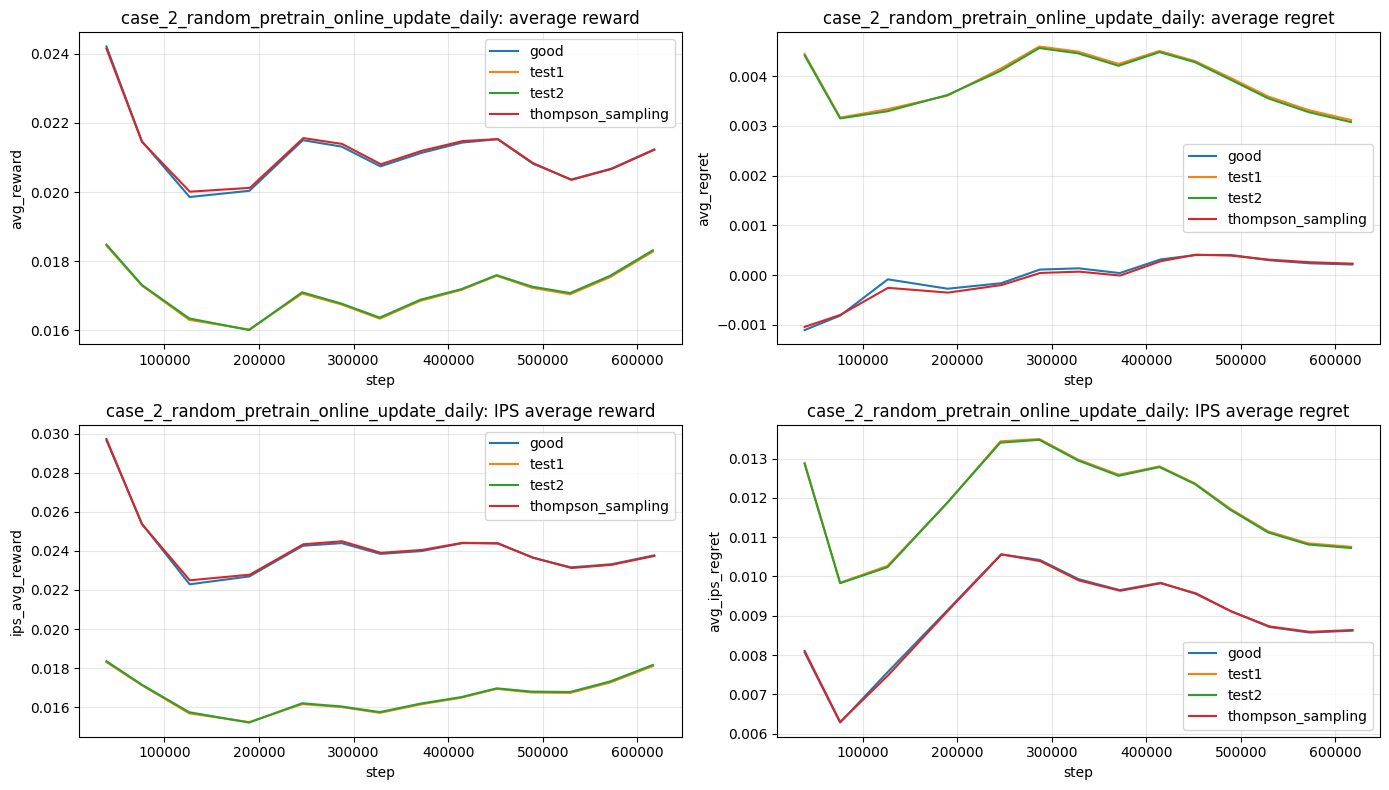

In [140]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')


## 6) График sensitive IPS metrics
Показывает `ips_ctr_sensitive` и `ips_regret_sens` по алгоритмам внутри каждого сценария.

In [ ]:
if set(sensitive_cols).issubset(metrics_df.columns):
    sensitive_plot_df = metrics_df[sensitive_cols].copy()
    sensitive_plot_df = sensitive_plot_df[sensitive_plot_df['sensitive_impressions'] > 0]

    if sensitive_plot_df.empty:
        print('Нет данных для sensitive IPS графика (sensitive_impressions == 0).')
    else:
        for scenario_name, part in sensitive_plot_df.groupby('scenario'):
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            part = part.sort_values('algo')

            axes[0].bar(part['algo'], part['ips_ctr_sensitive'])
            axes[0].set_title(f'{scenario_name}: sensitive IPS CTR')
            axes[0].set_xlabel('algo')
            axes[0].set_ylabel('ips_ctr_sensitive')
            axes[0].tick_params(axis='x', rotation=30)

            axes[1].bar(part['algo'], part['ips_regret_sens'])
            axes[1].set_title(f'{scenario_name}: sensitive IPS regret')
            axes[1].set_xlabel('algo')
            axes[1].set_ylabel('ips_regret_sens')
            axes[1].tick_params(axis='x', rotation=30)

            for ax in axes:
                ax.grid(True, alpha=0.3)

            fig.tight_layout()
            plt.show()
else:
    print('Sensitive IPS колонки отсутствуют в metrics_df.')


## 6.1) Sensitive IPS метрики по шагам
Показывает динамику sensitive-метрик, которые теперь логируются в `history_df`.


In [ ]:
if not history_df.empty and {'ips_ctr_sensitive_so_far', 'avg_ips_regret_sens_so_far'}.issubset(history_df.columns):
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df

            axes[0].plot(ds['step'], ds['ips_ctr_sensitive_so_far'], label=algo)
            axes[1].plot(ds['step'], ds['avg_ips_regret_sens_so_far'], label=algo)

        axes[0].set_title(f'{scenario_name}: sensitive IPS CTR (history)')
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('ips_ctr_sensitive_so_far')

        axes[1].set_title(f'{scenario_name}: sensitive IPS regret (history)')
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('avg_ips_regret_sens_so_far')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('Нет sensitive history-метрик в history_df.')


## 7) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

In [ ]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 8) Распределение показов по action и дням


In [139]:
action_daily_stats_df

,date,action,impressions_selected,scenario,algo
0,2026-02-05,1602,18,case_2_random_pretrain_online_update_daily,good
1,2026-02-05,4079,305,case_2_random_pretrain_online_update_daily,good
2,2026-02-05,5325,1,case_2_random_pretrain_online_update_daily,good
3,2026-02-05,5331,11,case_2_random_pretrain_online_update_daily,good
4,2026-02-05,5341,2,case_2_random_pretrain_online_update_daily,good
...,...,...,...,...,...
3765,2026-03-06,9491,203,case_2_random_pretrain_online_update_daily,thompson_sampling
3766,2026-03-06,9492,87,case_2_random_pretrain_online_update_daily,thompson_sampling
3767,2026-03-06,9493,202,case_2_random_pretrain_online_update_daily,thompson_sampling
3768,2026-03-06,9527,3227,case_2_random_pretrain_online_update_daily,thompson_sampling


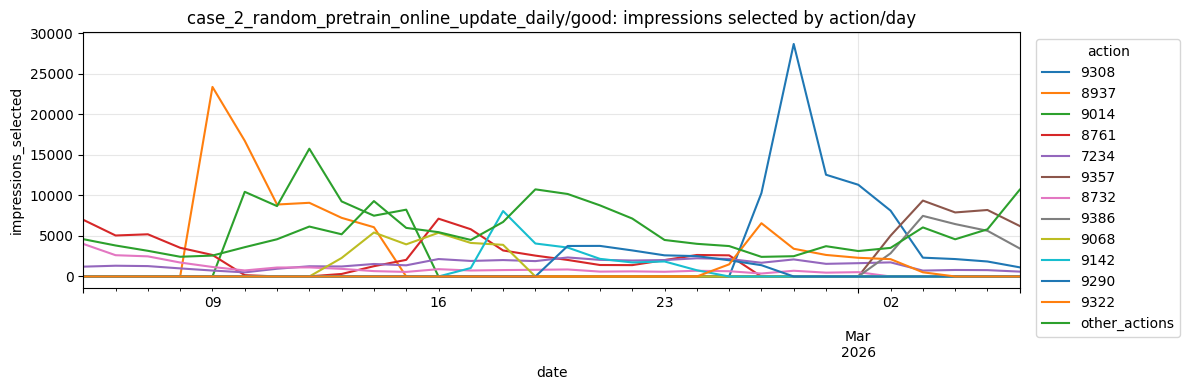

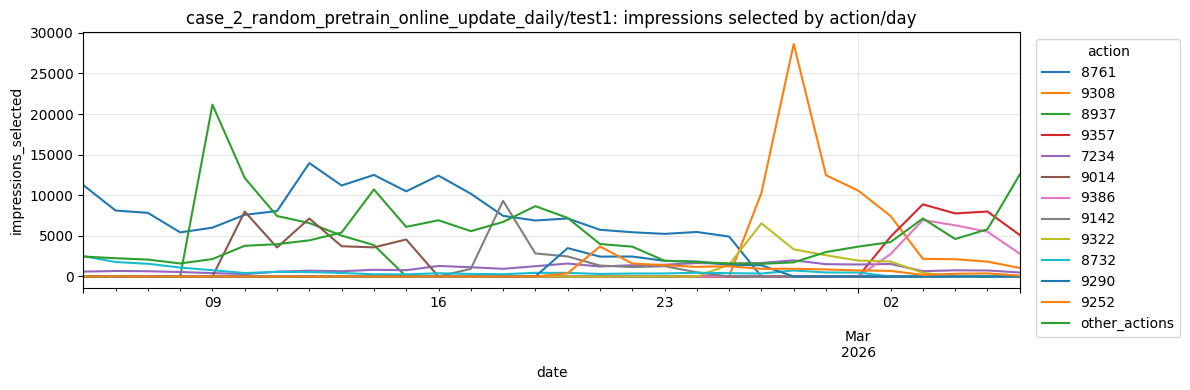

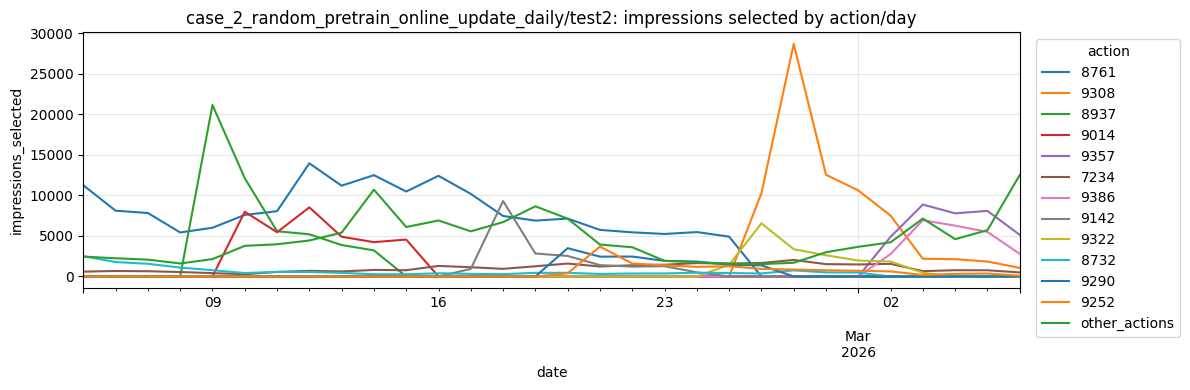

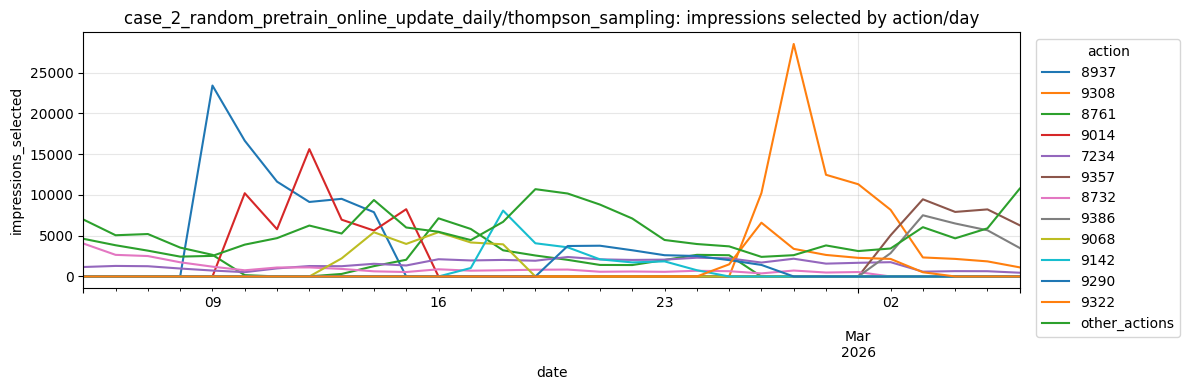

In [138]:
if not action_daily_stats_df.empty:
    top_actions_n = 12

    for scenario_name, part in action_daily_stats_df.groupby('scenario'):
        for algo_name, algo_df in part.groupby('algo'):
            pivot_cnt = algo_df.pivot_table(index='date', columns='action', values='impressions_selected', aggfunc='sum').fillna(0)

            if pivot_cnt.shape[1] > top_actions_n:
                action_totals = pivot_cnt.sum(axis=0).sort_values(ascending=False)
                top_actions = action_totals.head(top_actions_n).index
                other_actions = [a for a in pivot_cnt.columns if a not in top_actions]

                plot_df = pivot_cnt.loc[:, top_actions].copy()
                if other_actions:
                    plot_df['other_actions'] = pivot_cnt.loc[:, other_actions].sum(axis=1)
            else:
                plot_df = pivot_cnt.copy()

            fig, ax = plt.subplots(figsize=(12, 4))
            plot_df.sort_index().plot(ax=ax)
            ax.set_title(f'{scenario_name}/{algo_name}: impressions selected by action/day')
            ax.set_xlabel('date')
            ax.set_ylabel('impressions_selected')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title='action')
            fig.tight_layout()
            plt.show()
else:
    print('action_daily_stats_df is empty.')


## 9) Сохранение артефактов

In [ ]:
OUT_DIR = ARTIFACTS_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
metrics_offpolicy_path = OUT_DIR / 'metrics_offpolicy.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'
action_daily_stats_path = OUT_DIR / 'action_daily_stats.csv'
action_sensitive_stats_path = OUT_DIR / 'action_sensitive_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
metrics_offpolicy_df.to_csv(metrics_offpolicy_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)
action_daily_stats_df.to_csv(action_daily_stats_path, index=False)
action_sensitive_stats_df.to_csv(action_sensitive_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved offpolicy metrics:', metrics_offpolicy_path)
print('saved action stats:', action_stats_path)
print('saved action daily stats:', action_daily_stats_path)
print('saved action sensitive stats:', action_sensitive_stats_path)


bootstrap_summary_path = OUT_DIR / 'bootstrap_summary.csv'
bootstrap_runs_path = OUT_DIR / 'bootstrap_runs.csv'

if not bootstrap_summary_df.empty:
    bootstrap_summary_df.to_csv(bootstrap_summary_path, index=False)
    print('saved bootstrap summary:', bootstrap_summary_path)
if not bootstrap_runs_df.empty:
    bootstrap_runs_df.to_csv(bootstrap_runs_path, index=False)
    print('saved bootstrap runs:', bootstrap_runs_path)
